In [ ]:

# Import Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

In [ ]:
df = pd.read_csv('/content/Telco_Customer_Churn_Dataset (1)(1).csv')

In [ ]:
# Display first 5 rows
print("First 5 Rows:")
print(df.head())

First 5 Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies       

In [ ]:
# Dataset information
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

In [ ]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
# Data Cleaning
# Replace blank spaces with NaN
df=df.replace(" ", np.nan)
# Convert TotalCharges to numeric
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')
# Check missing values again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())
# Fill missing values in TotalCharges with median
imputer=SimpleImputer(strategy='median')
df['TotalCharges']=imputer.fit_transform(df[['TotalCharges']])


Missing Values After Cleaning:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
df.drop('customerID', axis=1, inplace=True)
# Convert target column Churn into numerical values
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])
# Encode all categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
# Display processed data
print("\nProcessed Dataset:")
print(df.head())


Processed Dataset:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0  

In [ ]:
# Features (X) and Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training Data Shape: (5634, 19)
Testing Data Shape: (1409, 19)


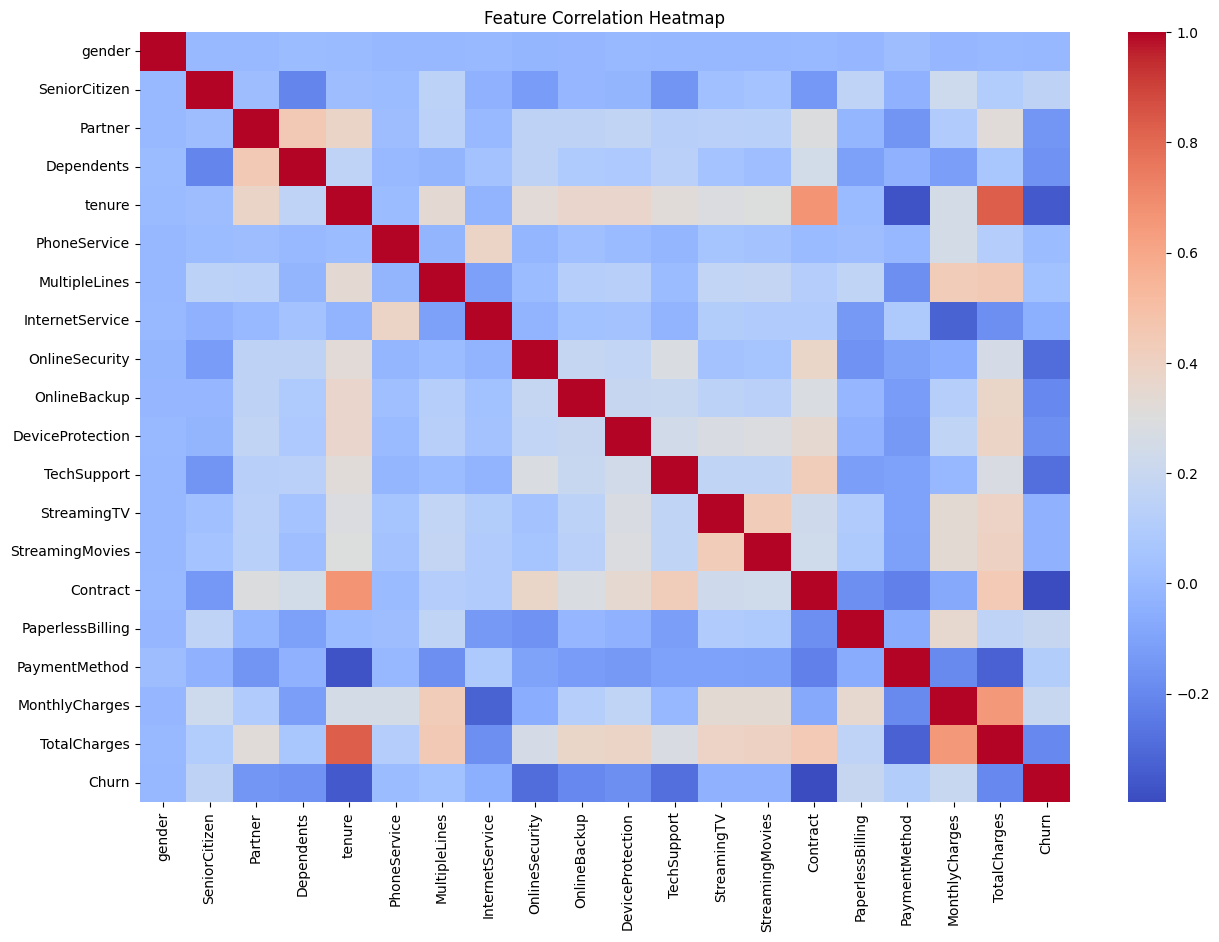


Features Correlated with Churn:
Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.199037
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64


In [ ]:
# Feature Correlation with Churn
correlation = df.corr()
# Plot heatmap
plt.figure(figsize=(15,10))
sns.heatmap(correlation, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()
# Show features most correlated with churn
churn_corr = correlation['Churn'].sort_values(ascending=False)
print("\nFeatures Correlated with Churn:")
print(churn_corr)

In [ ]:
# Model Selection
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


In [ ]:
# Model Training
results = []
for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]



In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
results.append([name, accuracy, precision, recall, f1, roc_auc])
print("\n====================================")
print(f"MODEL: {name}")
print("====================================")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


MODEL: Gradient Boosting
Accuracy  : 0.8013
Precision : 0.6655
Recall    : 0.5053
F1-Score  : 0.5745
ROC-AUC   : 0.8447

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



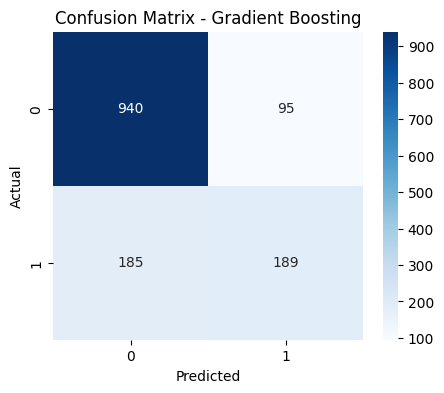

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {name}')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# COMPARE MODEL PERFORMANCE
results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
)
print("\n====================================")
print("MODEL COMPARISON")
print("====================================")
print(results_df)



MODEL COMPARISON
               Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Gradient Boosting  0.801278   0.665493  0.505348  0.574468  0.844748



Best Performing Model:
               Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Gradient Boosting  0.801278   0.665493  0.505348  0.574468  0.844748


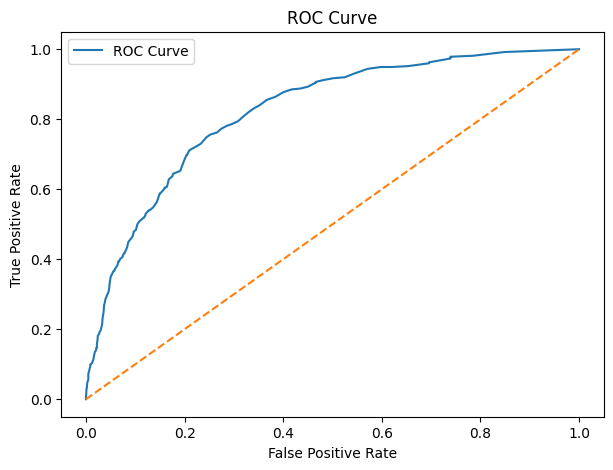

In [ ]:
# BEST MODEL SELECTION
best_model = results_df.sort_values(by='ROC-AUC', ascending=False)
print("\nBest Performing Model:")
print(best_model.head(1))
# ROC CURVE FOR BEST MODEL
best_classifier = RandomForestClassifier(random_state=42)
best_classifier.fit(X_train_scaled, y_train)
y_prob = best_classifier.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



In [ ]:
# FEATURE IMPORTANCE (Random Forest)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_classifier.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print("\nTop Important Features:")
print(feature_importance.head(10))



Top Important Features:
            Feature  Importance
18     TotalCharges    0.186841
17   MonthlyCharges    0.179192
4            tenure    0.154338
14         Contract    0.079631
16    PaymentMethod    0.050095
8    OnlineSecurity    0.049580
11      TechSupport    0.043603
0            gender    0.027892
7   InternetService    0.027789
9      OnlineBackup    0.027075


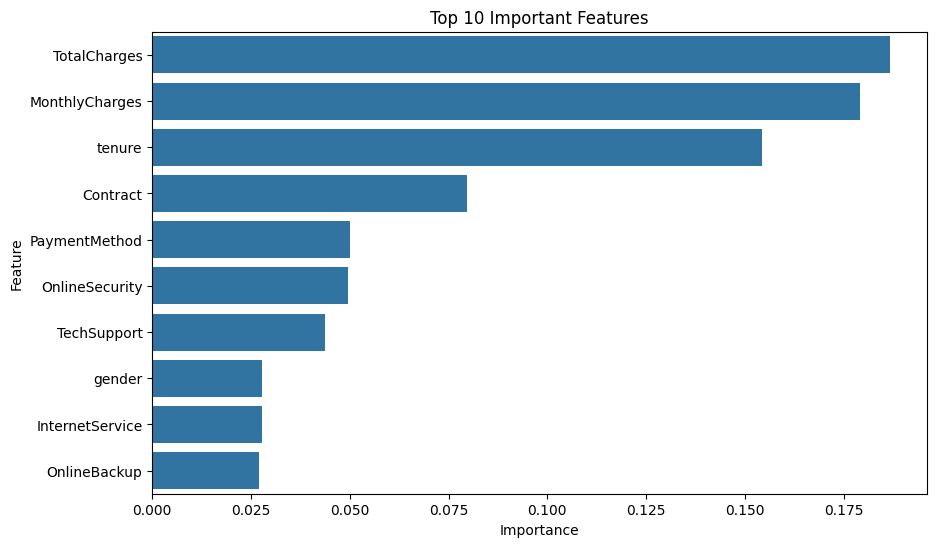


Project Completed Successfully!
Customer churn prediction model developed.


In [ ]:
# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title("Top 10 Important Features")
plt.show()
# FINAL INSIGHTS
print("\nProject Completed Successfully!")
print("Customer churn prediction model developed.")